# M4 - ML Assignment 1
Linear Regression Using ML Approach

 Business Context:
A retail company operates 2000 stores across multiple regions in Europe. This dataset represents store-level performance for one financial quarter. Marketing budgets are decided at the company level and allocated across stores. The objective is to predict quarterly sales using a machine learning-based linear regression model.

Dataset Description
Each row represents one store for one quarter.

Predictor Variables:
1. TV_Ad_Spend_EUR – Quarterly TV advertising spend allocated to the store (EUR)
2. Digital_Ad_Spend_EUR – Quarterly digital marketing spend (EUR)
3. Print_Ad_Spend_EUR – Quarterly print media spend (EUR)
4. Price_Discount_Percent – Average discount offered during the quarter (%)
5. Store_Visits – Number of customer visits during the quarter

Target Variable:
• Quarterly_Sales_EUR – Total sales revenue for the quarter (EUR)

Tasks
1. Load the dataset and perform basic exploratory checks.
2. Split the data into training (70%) and testing (30%) sets using a fixed random seed.
3. Fit a linear regression model using the training data.
4. Report the estimated regression coefficients.
5. Compute RMSE for the training dataset.
6. Compute RMSE for the test dataset.
7. Perform 5-fold cross-validation and report the RMSE for each fold and the mean RMSE.
8. Compare the RMSE values and comment on model generalization.
Conclusion
Students should discuss whether the linear regression model generalizes well to unseen data, and whether there is evidence of overfitting or underfitting based on RMSE comparisons.

In [136]:
import pandas as pd

df = pd.read_csv("M4 ASSIGNMENT 1 DATA.csv")
df.head()

,TV_Ad_Spend_EUR,Digital_Ad_Spend_EUR,Print_Ad_Spend_EUR,Price_Discount_Percent,Store_Visits,Quarterly_Sales_EUR
0,284658.290527,135559.552607,36004.483398,1.074174,5231.575136,663744.336717
1,128732.947281,127010.214487,193912.724653,7.017386,6870.648290,697050.110874
2,106203.552354,25459.827708,123787.873105,11.895431,6695.299765,508874.819088
3,229499.612251,266945.584398,36932.124498,4.575947,8858.916578,940806.012175
4,293398.208519,207796.831198,161809.898176,19.390237,3244.275457,960268.300483


In [137]:
df.dtypes

TV_Ad_Spend_EUR           float64
Digital_Ad_Spend_EUR      float64
Print_Ad_Spend_EUR        float64
Price_Discount_Percent    float64
Store_Visits              float64
Quarterly_Sales_EUR       float64
dtype: object

In [138]:
df.describe()

,TV_Ad_Spend_EUR,Digital_Ad_Spend_EUR,Print_Ad_Spend_EUR,Price_Discount_Percent,Store_Visits,Quarterly_Sales_EUR
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,209903.258663,156437.633972,102273.102375,12.540002,7925.819489,8.186136e+05
std,111203.463389,82037.704519,56136.480729,7.126397,4034.982511,2.263344e+05
min,20031.117293,15019.333919,5024.318706,0.007437,1003.795804,1.736646e+05
25%,112399.816830,85997.668903,51138.601595,6.364006,4213.490139,6.693849e+05
50%,208855.985573,158556.688382,105427.587513,12.582149,7995.151828,8.153716e+05
75%,305275.359985,226669.020931,149950.585622,18.506343,11454.763241,9.686762e+05
max,399864.815308,299818.338775,199978.562586,24.971284,14991.251819,1.564881e+06


In [139]:
df.isnull().sum()

TV_Ad_Spend_EUR           0
Digital_Ad_Spend_EUR      0
Print_Ad_Spend_EUR        0
Price_Discount_Percent    0
Store_Visits              0
Quarterly_Sales_EUR       0
dtype: int64

In [140]:
corr_matrix = df.corr()
print("Correlation Matrix:")
corr_matrix

Correlation Matrix:


,TV_Ad_Spend_EUR,Digital_Ad_Spend_EUR,Print_Ad_Spend_EUR,Price_Discount_Percent,Store_Visits,Quarterly_Sales_EUR
TV_Ad_Spend_EUR,1.000000,0.035231,0.031190,-0.011924,-0.034418,0.375964
Digital_Ad_Spend_EUR,0.035231,1.000000,-0.014443,-0.028326,0.006587,0.405421
Print_Ad_Spend_EUR,0.031190,-0.014443,1.000000,-0.000172,-0.032883,0.109256
Price_Discount_Percent,-0.011924,-0.028326,-0.000172,1.000000,-0.013550,0.449693
Store_Visits,-0.034418,0.006587,-0.032883,-0.013550,1.000000,0.499250
Quarterly_Sales_EUR,0.375964,0.405421,0.109256,0.449693,0.499250,1.000000


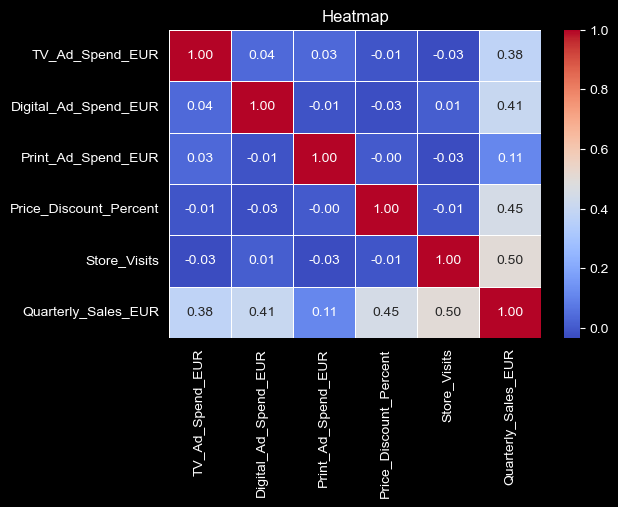

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap")
plt.show()

There is a negligible correlation between the different advertising channels, indicating low multicollinearity.
Additionally, `Print_Ad_Spend_EUR` shows only a very weak positive correlation (r = 0.11) with `Quarterly_Sales_EUR`, suggesting minimal linear influence on sales.


In [142]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy.highlevel import dmatrices

y1, X1 = dmatrices('Quarterly_Sales_EUR~TV_Ad_Spend_EUR+Digital_Ad_Spend_EUR+Print_Ad_Spend_EUR+Price_Discount_Percent+Store_Visits', data=df, return_type="dataframe")

vif = pd.Series([
    variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])
],index=X1.columns)
vif

Intercept                 18.951627
TV_Ad_Spend_EUR            1.003519
Digital_Ad_Spend_EUR       1.002315
Print_Ad_Spend_EUR         1.002225
Price_Discount_Percent     1.001113
Store_Visits               1.002446
dtype: float64

We can see from the table that there is no multicolinearity for this model, and we can proceed with a multilinear regression.

# Train-Test Split (70/30)

In [143]:
from sklearn.model_selection import train_test_split

X = df[['TV_Ad_Spend_EUR',
        'Digital_Ad_Spend_EUR',
        'Print_Ad_Spend_EUR',
        'Price_Discount_Percent',
        'Store_Visits']]

y = df['Quarterly_Sales_EUR']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Fit linear regression

In [144]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

In [145]:
model = pipeline.named_steps['model']

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)
print("Intercept:", model.intercept_)

                  Feature    Coefficient
0         TV_Ad_Spend_EUR   85580.020605
1    Digital_Ad_Spend_EUR   91386.308043
2      Print_Ad_Spend_EUR   26130.771383
3  Price_Discount_Percent  106265.464560
4            Store_Visits  120157.202742
Intercept: 822212.6446673829


The regression results indicate that Digital advertising has the highest marginal return among media channels. Price discount shows the strongest overall impact on quarterly sales, suggesting that promotional strategy plays a significant role in revenue generation. Store visits also demonstrate a substantial positive effect on sales performance.

In [146]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_train_pred = pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))

print("Training RMSE:", rmse_train)

Training RMSE: 102700.14360441543


In [147]:
from sklearn.metrics import r2_score

y_test_pred = pipeline.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("R2 Test:", r2_test)
print("Test RMSE:", rmse_test)

R2 Test: 0.7798455321037492
Test RMSE: 104052.47324161502


In [148]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

rmse_folds = -cv_scores
print("RMSE per fold:", rmse_folds)
print("Mean CV RMSE:", rmse_folds.mean())

RMSE per fold: [104680.53976129 108978.96746251 104787.44273998  98073.70352322
  99532.6611293 ]
Mean CV RMSE: 103210.6629232601


The linear regression model demonstrates strong generalization capability. The training RMSE (102,700), test RMSE (104,052), and mean cross-validation RMSE (103,210) are highly consistent, indicating low variance and no significant overfitting. The cross-validation results further confirm the stability of the model across different data splits. Therefore, the linear regression model provides a reliable predictive framework for quarterly sales.